
# Intravoxel incoherent motion (IVIM)
The intravoxel incoherent motion (IVIM) model describes diffusion
and perfusion in the signal acquired with a diffusion MRI sequence
that contains multiple low b-values. The IVIM model can be understood
as an adaptation of the work of Stejskal and Tanner :footcite:p:`Stejskal1965`
in biological tissue, and was proposed by Le Bihan :footcite:p:`LeBihan1988`.
The model assumes two compartments: a slow moving compartment,
where particles diffuse in a Brownian fashion as a consequence of thermal
energy, and a fast moving compartment (the vascular compartment), where
blood moves as a consequence of a pressure gradient. In the first compartment,
the diffusion coefficient is $\mathbf{D}$ while in the second compartment, a
pseudo diffusion term $\mathbf{D^*}$ is introduced that describes the
displacement of the blood elements in an assumed randomly laid out vascular
network, at the macroscopic level. According to :footcite:p:`LeBihan1988`,
$\mathbf{D^*}$ is greater than $\mathbf{D}$.

The IVIM model expresses the MRI signal as follows:

 .. math::
    S(b)=S_0(fe^{-bD^*}+(1-f)e^{-bD})

where $\mathbf{b}$ is the diffusion gradient weighing value (which is dependent
on the measurement parameters), $\mathbf{S_{0}}$ is the signal in the absence
of diffusion gradient sensitization, $\mathbf{f}$ is the perfusion
fraction, $\mathbf{D}$ is the diffusion coefficient and $\mathbf{D^*}$ is
the pseudo-diffusion constant, due to vascular contributions.

In the following example we show how to fit the IVIM model on a
diffusion-weighted dataset and visualize the diffusion and pseudo-diffusion
coefficients. First, we import all relevant modules:


In [1]:
import matplotlib.pyplot as plt

from dipy.core.gradients import gradient_table
from dipy.data import get_fnames
from dipy.io.gradients import read_bvals_bvecs
from dipy.io.image import load_nifti_data
from dipy.reconst.ivim import IvimModel

/Users/sarojrai/Desktop/LSBU/Dissertation /IVIM_Autoencoder/cvae/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


We get an IVIM dataset using DIPY_'s data fetcher ``read_ivim``.
This dataset was acquired with 21 b-values in 3 different directions.
Volumes corresponding to different directions were registered to each
other, and averaged across directions. Thus, this dataset has 4 dimensions,
with the length of the last dimension corresponding to the number
of b-values. In order to use this model the data should contain signals
measured at 0 bvalue.



In [2]:
fraw, fbval, fbvec = get_fnames(name="ivim")

[2026-08-02 09:34:18][dipy] INFO: Creating new folder /Users/sarojrai/.dipy/ivim
[2026-08-02 09:34:18][dipy] INFO: Downloading "ivim.nii.gz" to /Users/sarojrai/.dipy/ivim
[2026-08-02 09:34:18][dipy] INFO: From: https://ndownloader.figshare.com/files/5305243


100%|██████████| 16766/16766 MB [00:06]


[2026-08-02 09:34:29][dipy] INFO: Downloading "ivim.bval" to /Users/sarojrai/.dipy/ivim
[2026-08-02 09:34:29][dipy] INFO: From: https://ndownloader.figshare.com/files/5305246


100%|██████████| 1/1 MB [00:00]

[2026-08-02 09:34:31][dipy] WARNING: MD5 checksum mismatch for https://ndownloader.figshare.com/files/5305246. Retrying with alternate source...
[2026-08-02 09:34:31][dipy] INFO: Trying mirror server: https://workshop.dipy.org/services/data/files/5305246



100%|██████████| 1/1 MB [00:00]

[2026-08-02 09:34:31][dipy] INFO: Downloading "ivim.bvec" to /Users/sarojrai/.dipy/ivim
[2026-08-02 09:34:31][dipy] INFO: From: https://ndownloader.figshare.com/files/5305249



100%|██████████| 1/1 MB [00:00]

[2026-08-02 09:34:33][dipy] INFO: Files successfully downloaded to /Users/sarojrai/.dipy/ivim


The gtab contains a GradientTable object (information about the gradients
e.g. b-values and b-vectors). We get the data from the file using
``load_nifti_data``.



In [3]:
data = load_nifti_data(fraw)
bvals, bvecs = read_bvals_bvecs(fbval, fbvec)
gtab = gradient_table(bvals, bvecs=bvecs, b0_threshold=0)
print(f"data.shape {data.shape}")

data.shape (256, 256, 54, 21)


The data has 54 slices, with 256-by-256 voxels in each slice. The fourth
dimension corresponds to the b-values in the gtab. Let us visualize the data
by taking a slice midway(z=33) at $\mathbf{b} = 0$.



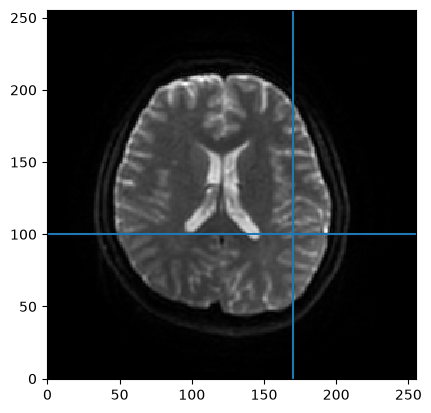

In [5]:
z = 33
b = 0

fig, ax = plt.subplots()
ax.imshow(data[:, :, z, b].T, origin="lower", cmap="gray", interpolation="nearest")
ax.axhline(y=100)
ax.axvline(x=170)
# fig.savefig("ivim_data_slice.png")
# plt.close(fig)
plt.show()

.. rst-class:: centered small fst-italic fw-semibold

Heat map of a slice of data


The region around the intersection of the cross-hairs in the figure
contains cerebral spinal fluid (CSF), so it should have a very high
$\mathbf{f}$ and $\mathbf{D^*}$, the area just medial to that is white
matter so that should be lower, and the region more laterally contains a
mixture of gray matter and CSF. That should give us some contrast to see
the values varying across the regions.



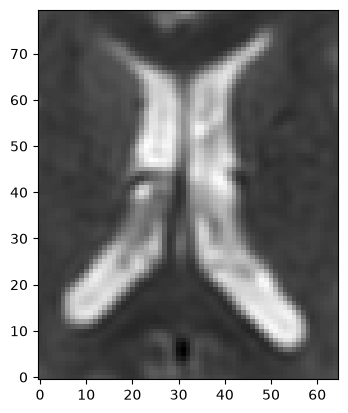

In [6]:
x1, x2 = 90, 155
y1, y2 = 90, 170
data_slice = data[x1:x2, y1:y2, z, :]

fig, ax = plt.subplots()
ax.imshow(
    data[x1:x2, y1:y2, z, b].T, origin="lower", cmap="gray", interpolation="nearest"
)
# fig.savefig("CSF_slice.png")
# plt.close(fig)
plt.show()

.. rst-class:: centered small fst-italic fw-semibold

Heat map of the CSF slice selected.


Now that we have prepared the datasets we can go forward with
the ivim fit. We provide two methods of fitting the parameters of the IVIM
multi-exponential model explained above. We first fit the model with a simple
fitting approach by passing the option `fit_method='trr'`. This method uses
a two-stage approach: first, a linear fit used to get quick initial guesses
for the parameters $\mathbf{S_{0}}$ and $\mathbf{D}$ by considering b-values
greater than ``split_b_D`` (default: 400))and assuming a mono-exponential
signal. This is based on the assumption that at high b-values the signal can
be approximated as a mono exponential decay and by taking the logarithm of
the signal values a linear fit can be obtained. Another linear fit for ``S0``
(bvals < ``split_b_S0`` (default: 200)) follows and ``f`` is estimated using
$1 - S0_{prime}/S0$. Then a non-linear least-squares fitting is performed to
fit ``D_star`` and ``f``. If the ``two_stage`` flag is set to ``True`` while
initializing the model, a final non-linear least squares fitting is performed
for all the parameters. All initializations for the model such as
``split_b_D`` are passed while creating the ``IvimModel``. If you are
using Scipy 0.17, you can also set bounds by setting
``bounds=([0., 0., 0.,0.], [np.inf, 1., 1., 1.]))`` while initializing the
``IvimModel``.

For brevity, we focus on a small section of the slice as selected above,
to fit the IVIM model. First, we instantiate the IvimModel object.



In [7]:
ivimmodel = IvimModel(gtab, fit_method="trr")

/Users/sarojrai/Desktop/LSBU/Dissertation /IVIM_Autoencoder/cvae/lib/python3.12/site-packages/dipy/testing/decorators.py:192: UserWarning: Bounds for this fit have been set from experiments and literature survey. To change the bounds, please input your bounds in model definition...
  return func(*args, **kwargs)


To fit the model, call the `fit` method and pass the data for fitting.



In [8]:
ivimfit = ivimmodel.fit(data_slice)

/Users/sarojrai/Desktop/LSBU/Dissertation /IVIM_Autoencoder/cvae/lib/python3.12/site-packages/dipy/reconst/ivim.py:332: UserWarning: x0 obtained from linear fitting is not feasible as initial guess for leastsq while estimating f and D_star. Using parameters from the linear fit.
  f, D_star = self.estimate_f_D_star(params_f_D_star, data, S0, D)
/Users/sarojrai/Desktop/LSBU/Dissertation /IVIM_Autoencoder/cvae/lib/python3.12/site-packages/dipy/reconst/ivim.py:336: UserWarning: x0 is unfeasible for leastsq fitting. Returning x0 values from the linear fit.
  params_two_stage = self._leastsq(data, params_linear)
/Users/sarojrai/Desktop/LSBU/Dissertation /IVIM_Autoencoder/cvae/lib/python3.12/site-packages/dipy/reconst/multi_voxel.py:282: UserWarning: Bounds are violated for leastsq fitting. Returning parameters from linear fit
  svf = single_voxel_fit(self, data[ijk], **kwargs)


The fit method creates a IvimFit object which contains the
parameters of the model obtained after fitting. These are accessible
through the `model_params` attribute of the IvimFit object.
The parameters are arranged as a 4D array, corresponding to the spatial
dimensions of the data, and the last dimension (of length 4)
corresponding to the model parameters according to the following
order : $\mathbf{S_{0}, f, D^*, D}$.



In [9]:
ivimparams = ivimfit.model_params
print(f"ivimparams.shape : {ivimparams.shape}")

ivimparams.shape : (65, 80, 4)


As we see, we have a 20x20 slice at the height z = 33. Thus we
have 400 voxels. We will now plot the parameters obtained from the
fit for a voxel and also various maps for the entire slice.
This will give us an idea about the diffusion and perfusion in
that section. Let(i, j) denote the coordinate of the voxel. We have
already fixed the z component as 33 and hence we will get a slice
which is 33 units above.



In [10]:
i, j = 10, 10
estimated_params = ivimfit.model_params[i, j, :]
print(estimated_params)

[3.97863115e+03 2.00000000e-01 1.69394248e-03 6.71052231e-04]


Now we can map the perfusion and diffusion maps for the slice. We
will plot a heatmap showing the values using a colormap. It will be
useful to define a plotting function for the heatmap here since we
will use it to plot for all the IVIM parameters. We will need to specify
the lower and upper limits for our data. For example, the perfusion
fractions should be in the range (0,1). Similarly, the diffusion and
pseudo-diffusion constants are much smaller than 1. We pass an argument
called ``variable`` to out plotting function which gives the label for
the plot.



In [12]:
def plot_map(raw_data, variable, limits, filename):
    fig, ax = plt.subplots(1)
    lower, upper = limits
    ax.set_title(f"Map for {variable}")
    im = ax.imshow(
        raw_data.T,
        origin="lower",
        clim=(lower, upper),
        cmap="gray",
        interpolation="nearest",
    )
    fig.colorbar(im)
    # fig.savefig(filename)
    plt.show()

Let us get the various plots with `fit_method = 'trr'` so that we can
visualize them in one page



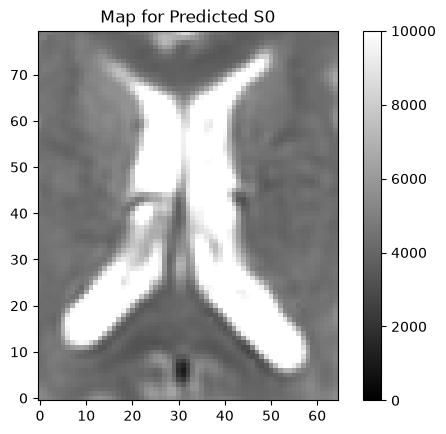

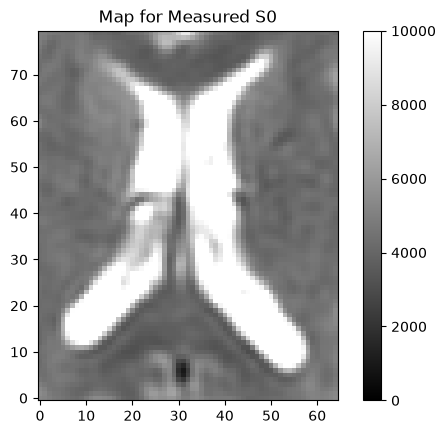

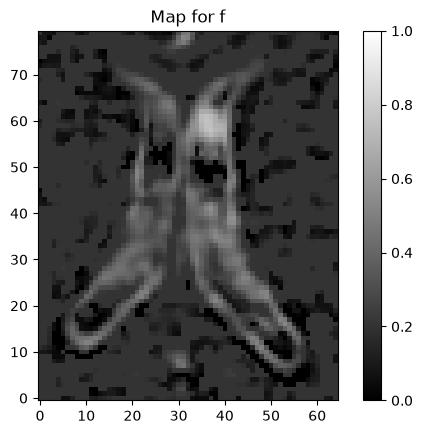

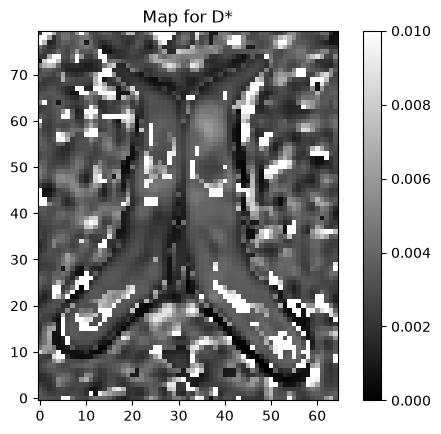

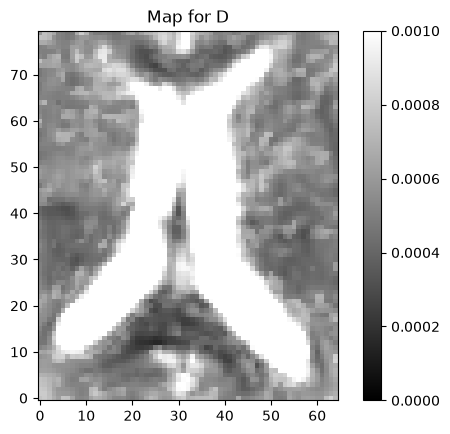

In [13]:
plot_map(ivimfit.S0_predicted, "Predicted S0", (0, 10000), "predicted_S0.png")
plot_map(data_slice[:, :, 0], "Measured S0", (0, 10000), "measured_S0.png")
plot_map(ivimfit.perfusion_fraction, "f", (0, 1), "perfusion_fraction.png")
plot_map(ivimfit.D_star, "D*", (0, 0.01), "perfusion_coeff.png")
plot_map(ivimfit.D, "D", (0, 0.001), "diffusion_coeff.png")

Next, we will fit the same model with a more refined optimization process
with `fit_method='VarPro'` (for "Variable Projection"). The VarPro computes
the IVIM parameters using the MIX approach :footcite:p:`Farooq2016`. This
algorithm uses three different optimizers. It starts with a differential
evolution algorithm and fits the parameters in the power of exponentials. Then
the fitted parameters in the first step are utilized to make a linear convex
problem. Using a convex optimization, the volume fractions are determined.
The last step is non-linear least-squares fitting on all the parameters.
The results of the first and second optimizers are utilized as the initial
values for the last step of the algorithm.

As opposed to the `'trr'` fitting method, this approach does not need to set
any thresholds on the bvals to differentiate between the perfusion
(pseudo-diffusion) and diffusion portions and fits the parameters
simultaneously. Making use of the three step optimization mentioned above
increases the convergence basin for fitting the multi-exponential functions
of microstructure models. This method has been described in further detail
in :footcite:p:`Fadnavis2019` and :footcite:p:`Farooq2016`.



In [16]:
!pip install cvxpy

/Users/sarojrai/Desktop/LSBU/Dissertation /IVIM_Autoencoder/cvae/bin/pip: line 2: /Users/sarojrai/Desktop/LSBU/Dissertation /IVIM_cvae/cvae/bin/python3: No such file or directory
/Users/sarojrai/Desktop/LSBU/Dissertation /IVIM_Autoencoder/cvae/bin/pip: line 2: exec: /Users/sarojrai/Desktop/LSBU/Dissertation /IVIM_cvae/cvae/bin/python3: cannot execute: No such file or directory


In [19]:
import sys

try:
    import cvxpy
except ModuleNotFoundError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "cvxpy"])
    import cvxpy

In [26]:
pip install cvxpy


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [32]:
import sys
import subprocess
import importlib

try:
    import cvxpy
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "cvxpy"])
    import cvxpy

import dipy.reconst.ivim as ivim_module
importlib.reload(ivim_module)
from dipy.reconst.ivim import IvimModel

ivimmodel_vp = IvimModel(gtab, fit_method="VarPro")
ivimfit_vp = ivimmodel_vp.fit(data_slice)

Just like the `'trr'` fit method, `'VarPro'` creates a IvimFit object which
contains the parameters of the model obtained after fitting. These are
accessible through the `model_params` attribute of the IvimFit object.
The parameters are arranged as a 4D array, corresponding to the spatial
dimensions of the data, and the last dimension (of length 4)
corresponding to the model parameters according to the following
order : $\mathbf{S_{0}, f, D^*, D}$.



In [33]:
i, j = 10, 10
estimated_params = ivimfit_vp.model_params[i, j, :]
print(estimated_params)

[4.15609783e+03 1.09732577e-01 9.86659301e-03 7.19170291e-04]


To compare the fit using `fit_method='VarPro'` and `fit_method='trr'`, we can
plot one voxel's signal and the model fit using both methods.

We will use the `predict` method of the IvimFit objects, to get the predicted
signal, based on each one of the model fit methods.



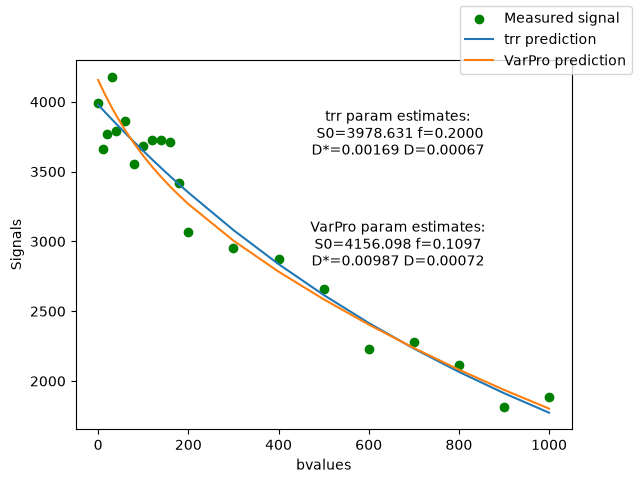

In [34]:
fig, ax = plt.subplots(1)

ax.scatter(gtab.bvals, data_slice[i, j, :], color="green", label="Measured signal")

ivim_trr_predict = ivimfit.predict(gtab)[i, j, :]

ax.plot(gtab.bvals, ivim_trr_predict, label="trr prediction")

S0_est, f_est, D_star_est, D_est = ivimfit.model_params[i, j, :]

trr_pro_param_est = (
    f"S0={S0_est:06.3f} f={f_est:06.4f}\nD*={D_star_est:06.5f} D={D_est:06.5f}"
)
text_fit = f"""trr param estimates:\n {trr_pro_param_est}"""

ax.text(
    0.65,
    0.80,
    text_fit,
    horizontalalignment="center",
    verticalalignment="center",
    transform=plt.gca().transAxes,
)

ivim_predict_vp = ivimfit_vp.predict(gtab)[i, j, :]
ax.plot(gtab.bvals, ivim_predict_vp, label="VarPro prediction")

ax.set_xlabel("bvalues")
ax.set_ylabel("Signals")

S0_est, f_est, D_star_est, D_est = ivimfit_vp.model_params[i, j, :]

var_pro_param_est = (
    f"S0={S0_est:06.3f} f={f_est:06.4f}\nD*={D_star_est:06.5f} D={D_est:06.5f}"
)
text_fit = f"""VarPro param estimates:\n{var_pro_param_est}"""

ax.text(
    0.65,
    0.50,
    text_fit,
    horizontalalignment="center",
    verticalalignment="center",
    transform=plt.gca().transAxes,
)

fig.legend(loc="upper right")
fig.savefig("ivim_voxel_plot.png")

.. rst-class:: centered small fst-italic fw-semibold

Plot of the signal from one voxel.


Let us get the various plots with `fit_method = 'VarPro'` so that we can
visualize them in one page



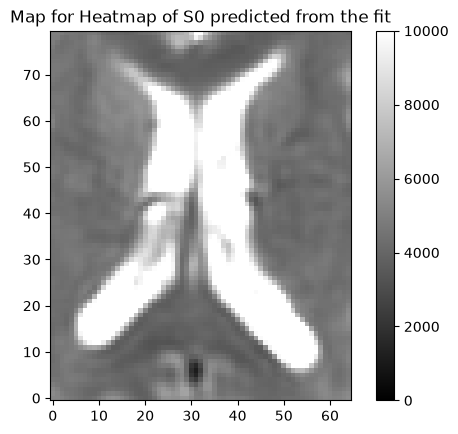

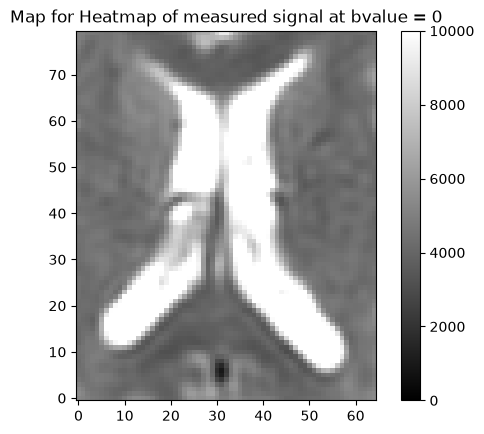

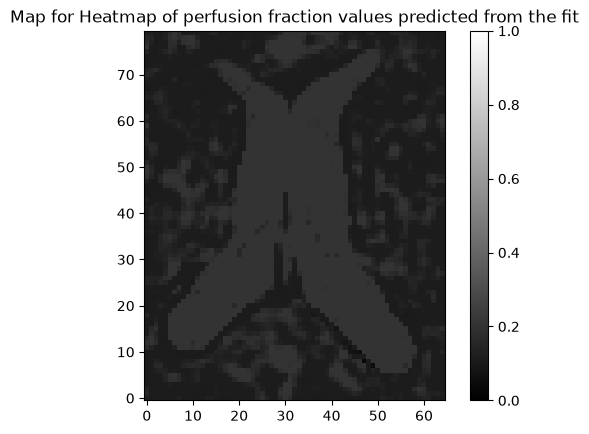

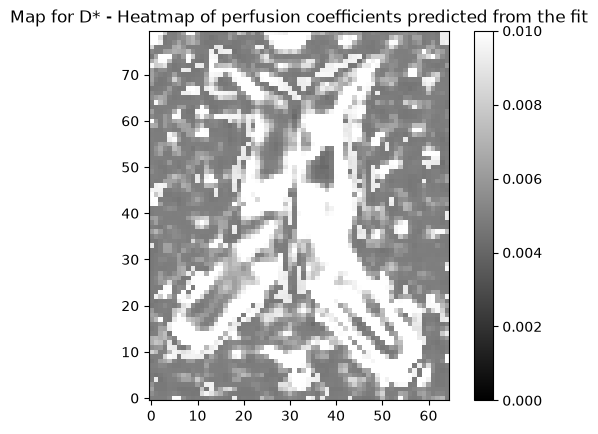

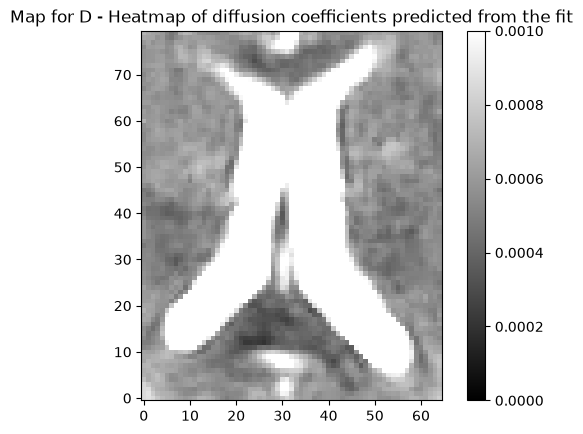

In [35]:
plot_map(
    ivimfit_vp.S0_predicted,
    "Heatmap of S0 predicted from the fit",
    (0, 10000),
    "predicted_S0.png",
)
plot_map(
    data_slice[..., 0],
    "Heatmap of measured signal at bvalue = 0",
    (0, 10000),
    "measured_S0.png",
)
plot_map(
    ivimfit_vp.perfusion_fraction,
    "Heatmap of perfusion fraction values predicted from the fit",
    (0, 1),
    "perfusion_fraction.png",
)
plot_map(
    ivimfit_vp.D_star,
    "D* - Heatmap of perfusion coefficients predicted from the fit",
    (0, 0.01),
    "perfusion_coeff.png",
)
plot_map(
    ivimfit_vp.D,
    "D - Heatmap of diffusion coefficients predicted from the fit",
    (0, 0.001),
    "diffusion_coeff.png",
)

## References

.. footbibliography::




.. include:: ../../links_names.inc


